In [90]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

from sklearn.metrics import classification_report,confusion_matrix,roc_curve

In [91]:
df=pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Data Exploration

Understand the structure of the dataset by checking the shape, columns, data types, and summary statistics.

In [92]:
df.shape

(768, 9)

In [93]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [95]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Check Missing Values

Check whether the dataset contains missing values.

In [96]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Histogram

Histograms show the distribution of numerical features.

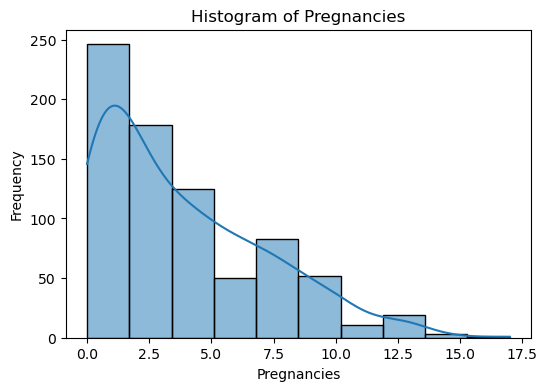

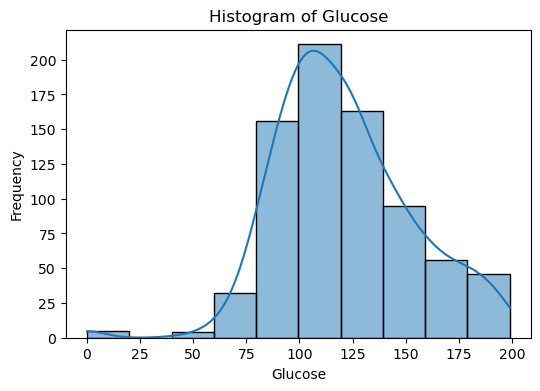

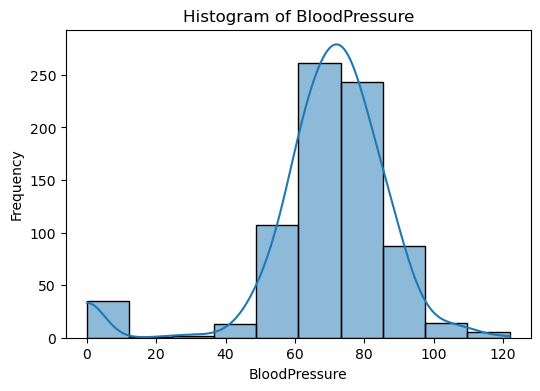

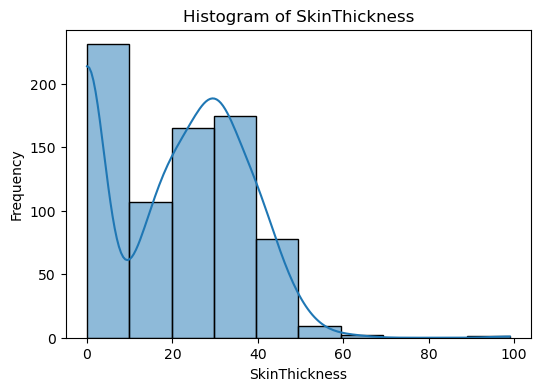

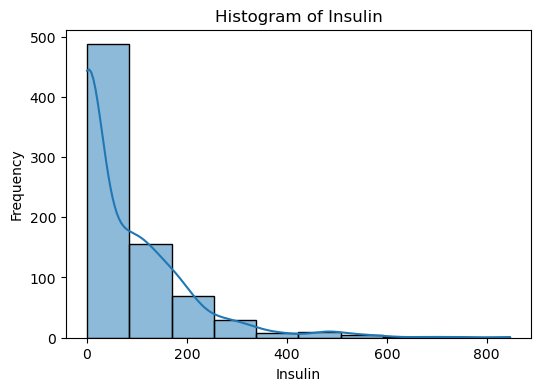

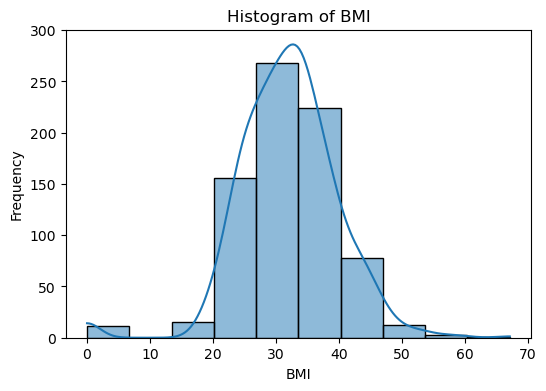

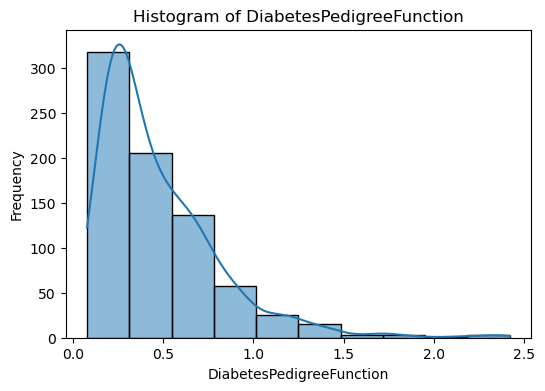

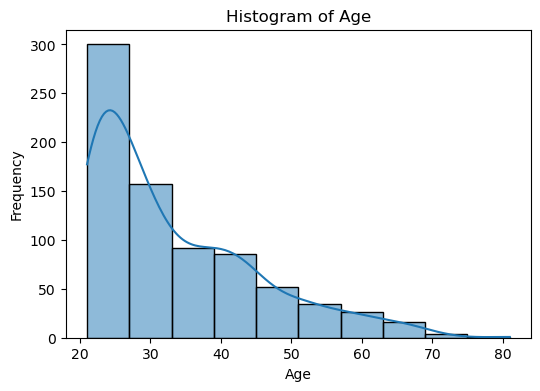

In [97]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for col in columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=10, kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

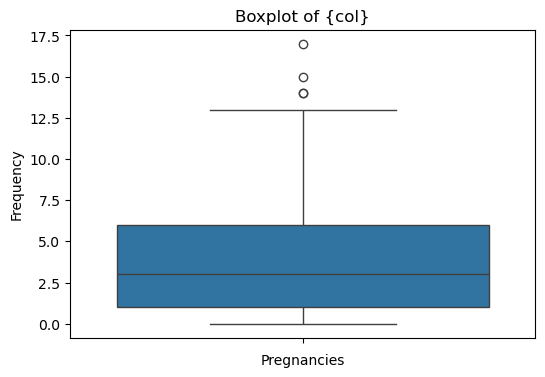

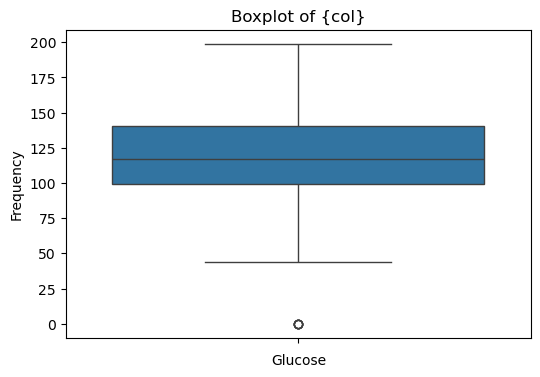

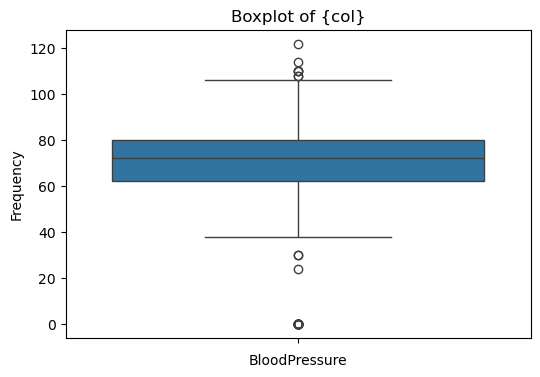

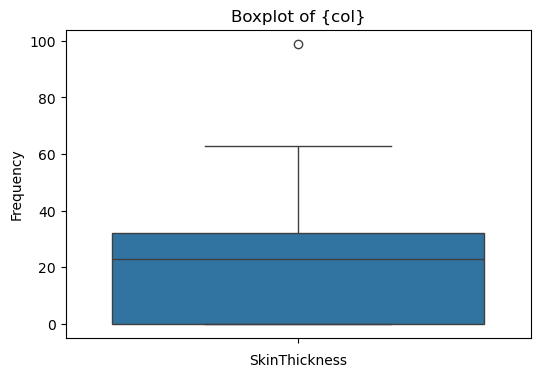

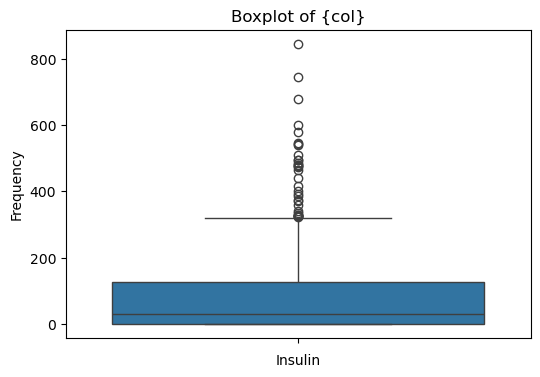

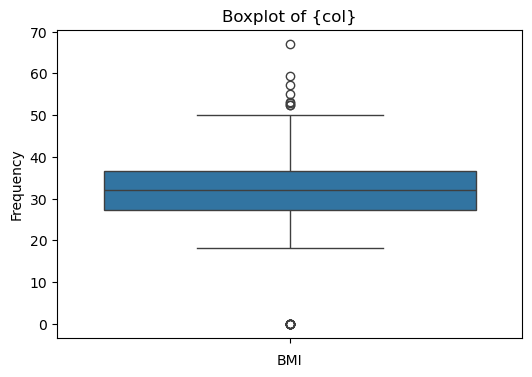

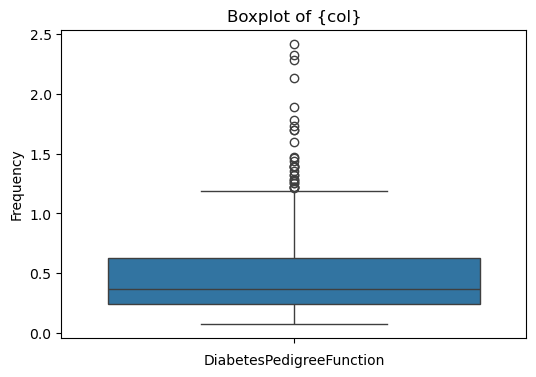

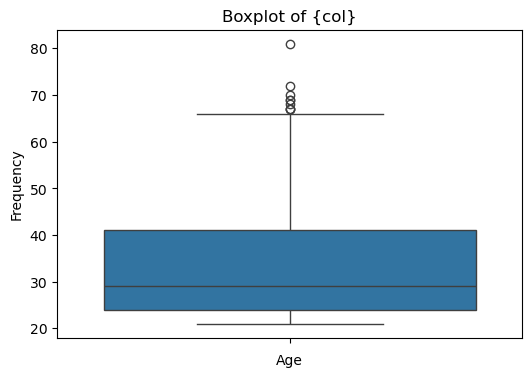

In [98]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for col in columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(df[col])
    plt.title('Boxplot of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Handle Outliers

The box plot showed the presence of outliers in some numerical features. To reduce their impact on the model, the outliers are handled using the Interquartile Range (IQR) method.

In [99]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

Verify Outlier Removal

After handling the outliers, box plots are generated again to verify whether the extreme values have been reduced.

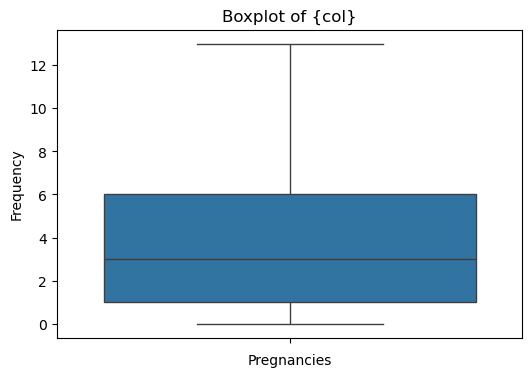

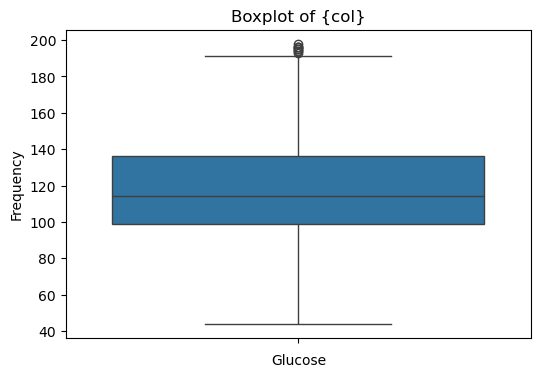

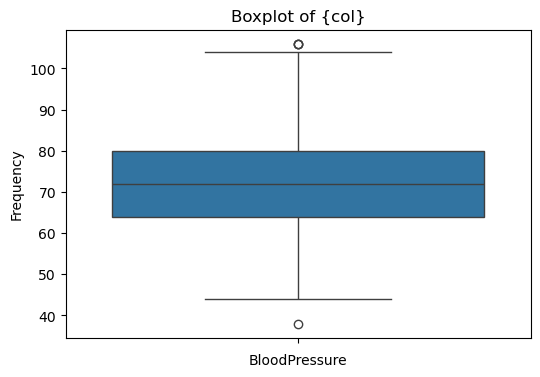

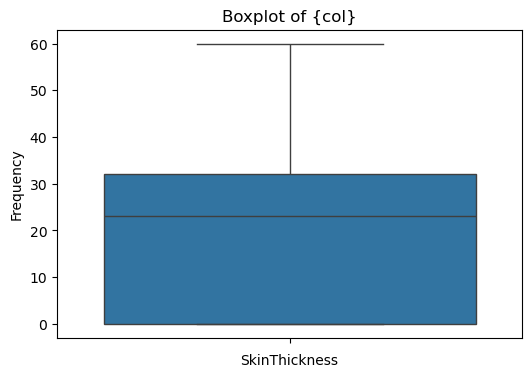

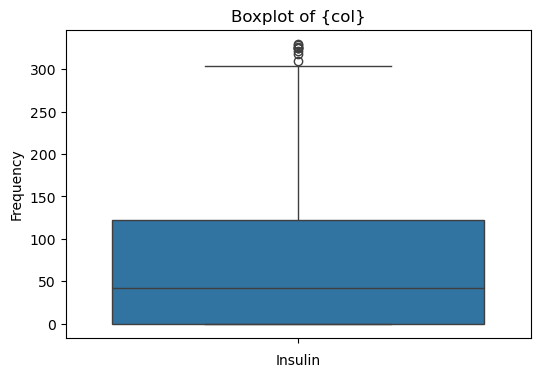

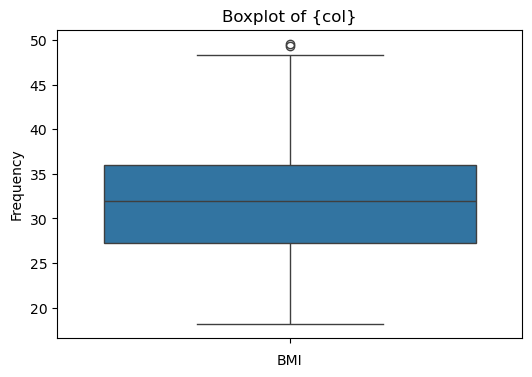

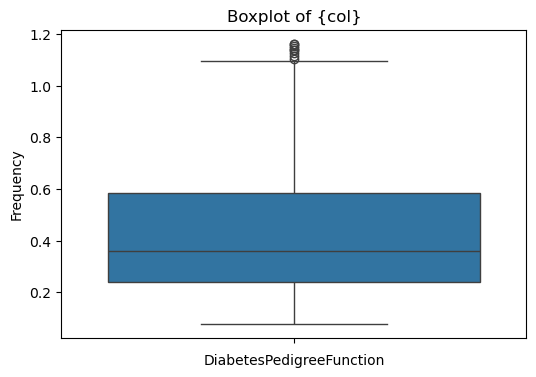

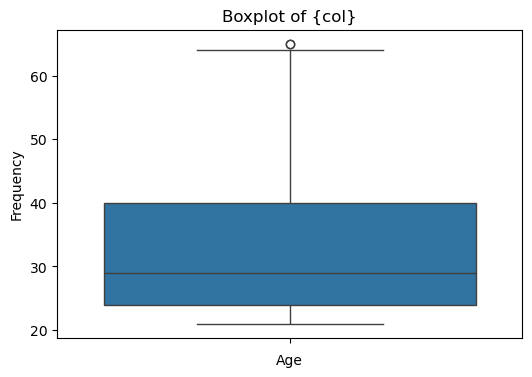

In [100]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for col in columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(df[col])
    plt.title('Boxplot of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [101]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.130759,0.206581,-0.088675,-0.090608,0.037389,-0.013274,0.582318,0.235631
Glucose,0.130759,1.000000,0.227750,0.017161,0.280328,0.193989,0.051546,0.268977,0.493355
BloodPressure,0.206581,0.227750,1.000000,0.039799,-0.019897,0.290307,0.022308,0.345872,0.171178
SkinThickness,-0.088675,0.017161,0.039799,1.000000,0.475258,0.383783,0.165758,-0.122427,0.042490
Insulin,-0.090608,0.280328,-0.019897,0.475258,1.000000,0.177380,0.225171,-0.053711,0.114653
BMI,0.037389,0.193989,0.290307,0.383783,0.177380,1.000000,0.148256,0.066110,0.268268
DiabetesPedigreeFunction,-0.013274,0.051546,0.022308,0.165758,0.225171,0.148256,1.000000,0.031168,0.168112
Age,0.582318,0.268977,0.345872,-0.122427,-0.053711,0.066110,0.031168,1.000000,0.267017
Outcome,0.235631,0.493355,0.171178,0.042490,0.114653,0.268268,0.168112,0.267017,1.000000


#Correlation Heatmap

A heatmap is used to understand the correlation among different numerical features.

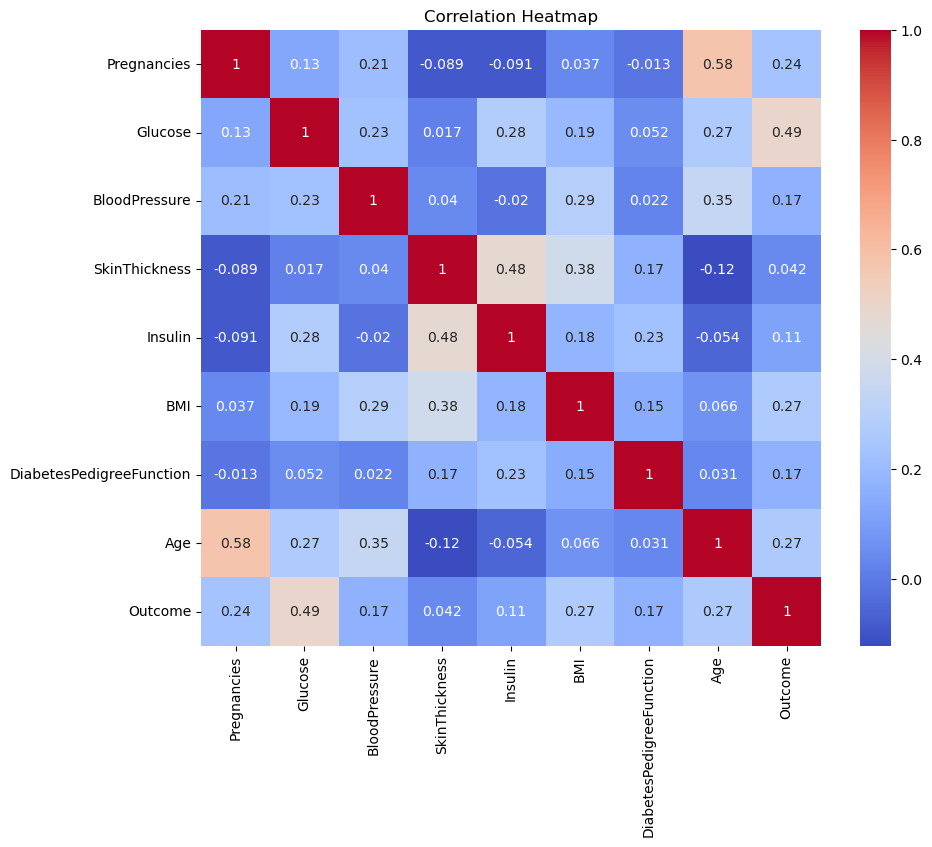

In [102]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#Observations

- BMI has the highest positive correlation with the Outcome variable.
- Glucose also shows a strong positive relationship with diabetes.
- Age and Pregnancies have a moderate positive correlation.
- Some numerical features contain outliers, which are handled during preprocessing.

#Data Preprocessing

Replace invalid zero values with missing values and fill them using the median.

In [103]:
cols=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[cols]=df[cols].replace(0,np.nan)

df.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               173
Insulin                     300
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [104]:
for col in cols:
    df[col]=df[col].fillna(df[col].median())

In [105]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

No categorical variables are present in this dataset. Therefore, encoding is not required.

Split Features and Target Variable

In [106]:
X=df.drop("Outcome",axis=1)

y=df["Outcome"]

Split the Dataset into Training and Testing Sets

In [107]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature Scaling

Standardize the numerical features using StandardScaler.

In [108]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

#Build Logistic Regression Model

In [109]:
model=LogisticRegression()

model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [110]:
#prediction
predictions = model.predict(X_test)
print(predictions)

[1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1
 0 0 1 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


In [111]:
# Evaluation
conf_matrix = confusion_matrix(y_test, predictions)
accuracy = accuracy_score(y_test, predictions)

print(conf_matrix)
print(accuracy)
print(classification_report(y_test,predictions))

[[81 11]
 [23 13]]
0.734375
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        92
           1       0.54      0.36      0.43        36

    accuracy                           0.73       128
   macro avg       0.66      0.62      0.63       128
weighted avg       0.71      0.73      0.72       128



In [112]:
train_score = model.score(X_train, y_train)
print("Train Score:", train_score)
train_score = model.score(X_train, y_train)
print("Train Score:", train_score)

Train Score: 0.7893700787401575
Train Score: 0.7893700787401575


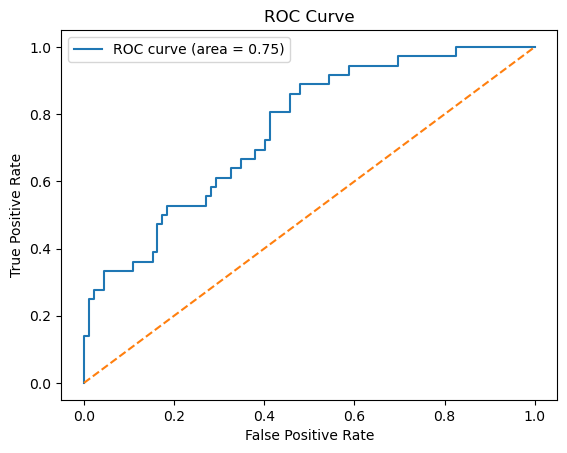

AUC Score: 0.7542270531400966


In [113]:

from sklearn.metrics import roc_curve, auc

# Probability predictions on test data
y_pred_proba = model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

In [114]:
coef=pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_[0]
})

coef.sort_values(by="Coefficient",ascending=False)

,Feature,Coefficient
1,Glucose,1.229731
5,BMI,0.501500
0,Pregnancies,0.420074
6,DiabetesPedigreeFunction,0.353882
7,Age,0.311959
3,SkinThickness,0.076363
4,Insulin,0.028087
2,BloodPressure,-0.119223


In [115]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Interpretation
A positive coefficient indicates that the feature increases the probability of diabetes.
A negative coefficient indicates that the feature decreases the probability of diabetes.
Features with larger absolute coefficients have a stronger influence on prediction.
b. Significance of Features

Based on the Logistic Regression coefficients, Glucose, BMI, Age, and DiabetesPedigreeFunction are among the most influential features for predicting diabetes. Higher glucose levels and BMI increase the likelihood of diabetes. Age and family history (DiabetesPedigreeFunction) also contribute to the prediction. These features help the model distinguish between diabetic and non-diabetic patients.

Conclusion

The Logistic Regression model was successfully developed to predict diabetes using patient health data. Exploratory Data Analysis (EDA) helped identify key relationships among variables. Missing values were handled by replacing invalid zero values with the median. The model was trained and evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, and the ROC Curve. Feature interpretation showed that Glucose, BMI, Age, and DiabetesPedigreeFunction are significant predictors of diabetes. Finally, the trained model and scaler were saved and deployed through a Streamlit application, allowing users to enter patient information and receive diabetes predictions through an interactive web interface.

In [116]:
import pickle

# Save the trained model
pickle.dump(model, open("diabetes_model.pkl", "wb"))

# Save the scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model and Scaler saved successfully.")

Model and Scaler saved successfully.


In [117]:
import os

print(os.getcwd())

C:\Users\gurra


In [118]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


Interview Questions:
--------------------

1. Difference Between Precision and Recall:

Precision: Precision measures how many predicted positive cases are actually positive.
Formula:
Precision = TP / (TP + FP)
High precision means fewer false positive predictions.

Recall:Recall measures how many actual positive cases are correctly identified by the model.
Formula:
Recall = TP / (TP + FN)
High recall means fewer false negative predictions.


2. What is Cross-Validation and Why is it Important?

Cross-validation is a technique used to evaluate machine learning models by dividing the dataset into multiple parts (folds).
The model is trained on some folds and tested on the remaining fold. This process repeats multiple times.

Importance of Cross-Validation:
1. Helps evaluate model performance more accurately.
2. Reduces overfitting.
3. Ensures the model generalizes well to new data.
4. Makes better use of limited datasets.
5. Improves reliability of classification results.